# 227 — kmerseek recall vs domain length

Notebook [226](./226_how_much_of_the_answer_key_is_reachable.ipynb) §5.3 found that
kmerseek's true positives come from the short end of the answer key (mean length fraction
0.228 against 0.362 for phmmer) and that its low recall is a sensitivity limit, not a
boundary limit: it matches the boundary on 80% of the domains it reaches at all. It did not ask how recall
depends on domain length. This notebook does, for every arm, and then asks whether the
length effect is really an identity effect in disguise, since short domains in this answer
key are also the better-conserved ones.

Same run as 220-226 (midi-plus), pfam truth set, nine target species, and all 998 queries
(2,435 truth instances, 1,798 (protein, family) pairs) rather than the 964 chromosome 6
proteins 226 used. Two restrictions throughout:

- Only cells whose Pfam family is present in the target proteome. 226 showed the absent
  class is a hard floor for every tool, so it would only dilute every band by the same
  factor.
- Unit is the (query protein, Pfam family, species) cell, as in 226 §4, because the call
  table does not say which instance of a repeated family a call matched. Domain length is
  the longest instance of that family on that protein.

Domain length bands are <50, 50-100, 100-200 and ≥200 aa. The median true domain is 90 aa
(226 §1), so the middle two bands hold most of the key.

Run: QfO Pfam-region benchmark, midi-plus (2026-09-01 to 09-02, 4,723 tasks). 998 human queries: 964 chromosome 6 proteins plus B2M, CD1A-E, MR1 and 27 KIR/LILR receptors. Targets: mouse, chicken, zebrafish, ciona, fly, worm, yeast, Arabidopsis and E. coli, all scored against Pfam; Botryllus schlosseri searched but unscored.

truth instances: 2435, (protein, family) pairs: 1798
cells with the family present in the target: 10,647 of 16,182
arms: 16 (7 kmerseek)

Domain length bands, families present in the target:
shape: (4, 4)
┌─────────┬─────────┬────────────┬─────────┐
│ band    ┆ n_pairs ┆ median_len ┆ n_cells │
│ ---     ┆ ---     ┆ ---        ┆ ---     │
│ str     ┆ u32     ┆ f64        ┆ u32     │
╞═════════╪═════════╪════════════╪═════════╡
│ <50     ┆ 249     ┆ 38.0       ┆ 1458    │
│ 50-100  ┆ 610     ┆ 79.0       ┆ 3487    │
│ 100-200 ┆ 548     ┆ 131.0      ┆ 3252    │
│ >=200   ┆ 391     ┆ 278.0      ┆ 2450    │
└─────────┴─────────┴────────────┴─────────┘


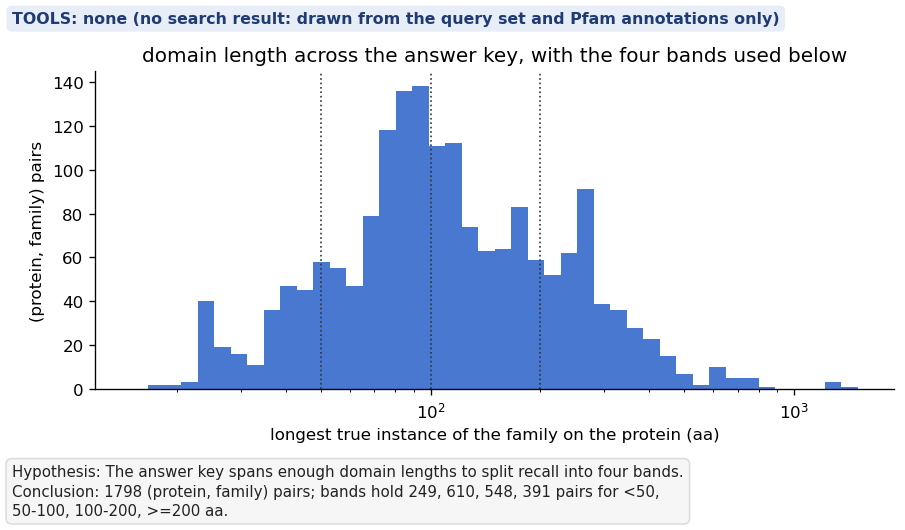

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

SP = mu.SPECIES_ORDER
BANDS = ["<50", "50-100", "100-200", ">=200"]
BAND_LABELS = ["<50 aa", "50-100", "100-200", ">=200"]
KM_BEST = "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"
PHMMER = "hmmer3_phmmer.default"
FOLDSEEK = "foldseek.3di_aa"


def length_band(col: pl.Expr) -> pl.Expr:
    return (
        pl.when(col < 50)
        .then(pl.lit("<50"))
        .when(col < 100)
        .then(pl.lit("50-100"))
        .when(col < 200)
        .then(pl.lit("100-200"))
        .otherwise(pl.lit(">=200"))
    )


TRUTH = mu.load_human_truth()
PAIRS = (
    TRUTH.with_columns(dlen=pl.col("domain_end") - pl.col("domain_start") + 1)
    .group_by("accession", "pfam_id")
    .agg(
        dlen=pl.col("dlen").max(),
        plen=pl.col("protein_length").first(),
        n_instances=pl.len(),
    )
    .rename({"accession": "query_acc"})
    .with_columns(band=length_band(pl.col("dlen")))
)
PRESENT = mu.target_family_counts(PAIRS["pfam_id"].unique().to_list()).filter(
    pl.col("n_target_proteins") > 0
)
GRID = (
    mu.domain_grid(PAIRS, SP)
    .join(PRESENT.select("species", "pfam_id"), on=["species", "pfam_id"], how="inner")
    .with_columns(
        boundary_matched=pl.col("best_iou") >= 0.5,
        covered=pl.col("best_cover") >= 0.5,
        called=pl.col("n_calls") > 0,
    )
)
ARMS = GRID["arm"].unique().sort().to_list()
KM_ARMS = [a for a in ARMS if a.startswith("kmerseek.")]
N_CELLS = GRID.select("query_acc", "pfam_id", "species").n_unique()

print(mu.RUN_SUMMARY)
print()
print(f"truth instances: {TRUTH.height}, (protein, family) pairs: {PAIRS.height}")
print(f"cells with the family present in the target: {N_CELLS:,} of {PAIRS.height * len(SP):,}")
print(f"arms: {len(ARMS)} ({len(KM_ARMS)} kmerseek)")
print()
per_band = (
    PAIRS.group_by("band")
    .agg(n_pairs=pl.len(), median_len=pl.col("dlen").median())
    .join(
        GRID.filter(pl.col("arm") == KM_BEST).group_by("band").agg(n_cells=pl.len()),
        on="band",
    )
    .with_columns(_o=pl.col("band").replace_strict(dict(zip(BANDS, range(4)))))
    .sort("_o")
    .drop("_o")
)
print("Domain length bands, families present in the target:")
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(per_band)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(PAIRS["dlen"], bins=np.logspace(np.log10(15), np.log10(1500), 45), color="#4878CF")
for x in (50, 100, 200):
    ax.axvline(x, color="#333333", ls=":", lw=1)
ax.set_xscale("log")
ax.set_xlabel("longest true instance of the family on the protein (aa)")
ax.set_ylabel("(protein, family) pairs")
ax.set_title("domain length across the answer key, with the four bands used below")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "227_length_bands.png",
    tools=mu.NO_TOOL,
    hypothesis="The answer key spans enough domain lengths to split recall into four bands.",
    conclusion=(
        f"{PAIRS.height} (protein, family) pairs; bands hold "
        + ", ".join(f"{r['n_pairs']}" for r in per_band.iter_rows(named=True))
        + " pairs for <50, 50-100, 100-200, >=200 aa."
    ),
)

## 1. Recall by domain length, every arm

Two ways of scoring the same cell, as in 226: boundary matched (best IoU ≥ 0.5, the pipeline's
rule for every arm but folddisco) and covered (at least half the true domain inside some
call, folddisco's rule). Folddisco is drawn on both panels; only the covered panel is its
own rule.

Boundary matched (IoU >= 0.5) by domain length band, families present in the target:
shape: (16, 6)
┌──────────────────────────────────────┬───────┬────────┬─────────┬───────┬───────────────────────┐
│ arm                                  ┆ <50   ┆ 50-100 ┆ 100-200 ┆ >=200 ┆ ratio_short_over_long │
│ ---                                  ┆ ---   ┆ ---    ┆ ---     ┆ ---   ┆ ---                   │
│ str                                  ┆ f64   ┆ f64    ┆ f64     ┆ f64   ┆ f64                   │
╞══════════════════════════════════════╪═══════╪════════╪═════════╪═══════╪═══════════════════════╡
│ folddisco.motif                      ┆ 0.005 ┆ 0.108  ┆ 0.149   ┆ 0.519 ┆ 0.010                 │
│ reseek.verysensitive                 ┆ 0.107 ┆ 0.305  ┆ 0.395   ┆ 0.745 ┆ 0.140                 │
│ prostt5.3di_from_seq                 ┆ 0.158 ┆ 0.416  ┆ 0.495   ┆ 0.806 ┆ 0.200                 │
│ foldseek.3di_aa                      ┆ 0.193 ┆ 0.430  ┆ 0.513   ┆ 0.805 ┆ 0.240                 │


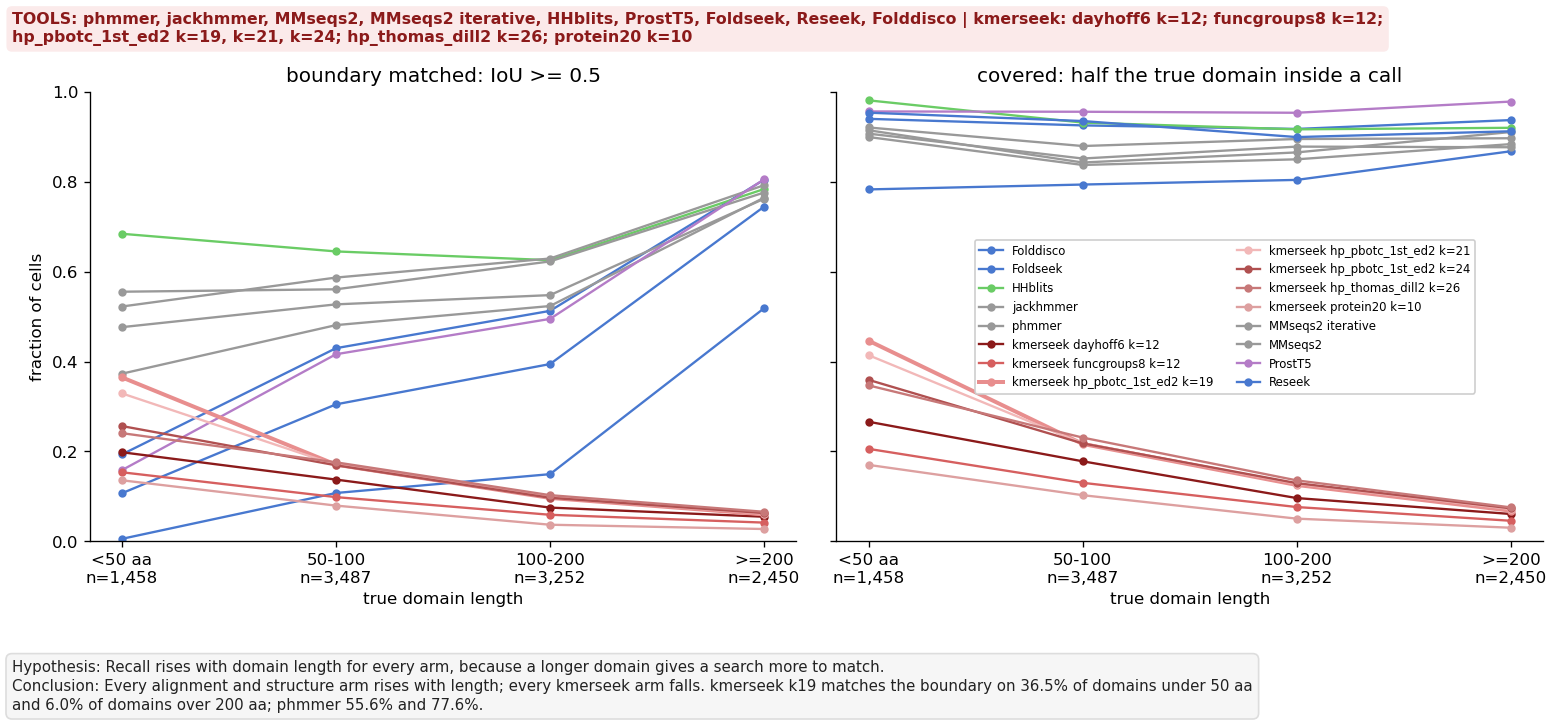

In [2]:
by_band = (
    GRID.group_by("arm", "band")
    .agg(
        n=pl.len(),
        boundary_matched=pl.col("boundary_matched").mean(),
        covered=pl.col("covered").mean(),
        called=pl.col("called").mean(),
    )
    .with_columns(_o=pl.col("band").replace_strict(dict(zip(BANDS, range(4)))))
    .sort("arm", "_o")
    .drop("_o")
)
wide = by_band.pivot(on="band", index="arm", values="boundary_matched").select(["arm"] + BANDS)
wide = wide.with_columns(
    ratio_short_over_long=(pl.col("<50") / pl.col(">=200")).round(2)
).sort("ratio_short_over_long")
print("Boundary matched (IoU >= 0.5) by domain length band, families present in the target:")
with pl.Config(tbl_rows=20, tbl_width_chars=160, fmt_str_lengths=45, float_precision=3):
    print(wide)

km_row = wide.filter(pl.col("arm") == KM_BEST).row(0, named=True)
ph_row = wide.filter(pl.col("arm") == PHMMER).row(0, named=True)
print()
print(f"kmerseek k19 vs phmmer, boundary matched: <50 aa {km_row['<50']:.3f} vs {ph_row['<50']:.3f} "
      f"({km_row['<50'] / ph_row['<50']:.0%}); >=200 aa {km_row['>=200']:.3f} vs "
      f"{ph_row['>=200']:.3f} ({km_row['>=200'] / ph_row['>=200']:.0%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
x = np.arange(4)
km_shades = ["#8B1A1A", "#D65F5F", "#E88E8E", "#F2B8B8", "#B05050", "#C77878", "#DDA0A0"]
for ax, col, title in zip(
    axes, ["boundary_matched", "covered"],
    ["boundary matched: IoU >= 0.5", "covered: half the true domain inside a call"],
):
    for arm in ARMS:
        tool = arm.split(".")[0]
        sub = by_band.filter(pl.col("arm") == arm)
        y = [sub.filter(pl.col("band") == b)[col][0] for b in BANDS]
        if tool == "kmerseek":
            c = km_shades[KM_ARMS.index(arm)]
            lw, z = (2.4 if arm == KM_BEST else 1.4), 3
        else:
            c = mu.TOOL_FAMILY_COLORS[mu.TOOL_FAMILY[tool]]
            lw, z = 1.4, 2
        ax.plot(x, y, "o-", color=c, lw=lw, zorder=z, label=mu.arm_pretty(arm), ms=4)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{b}\nn={n:,}" for b, n in zip(BAND_LABELS, per_band["n_cells"])]
    )
    ax.set_xlabel("true domain length")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("fraction of cells")
axes[1].legend(fontsize=7, ncol=2, loc="center", bbox_to_anchor=(0.55, 0.5), framealpha=0.95)
mu.finish_figure(
    fig,
    FIG_DIR / "227_recall_by_length.png",
    tools=mu.tools_text(mu.COMPARISON_TOOLS, kmerseek=[a.split(".", 1)[1] for a in KM_ARMS]),
    hypothesis="Recall rises with domain length for every arm, because a longer domain gives a search more to match.",
    conclusion=(
        f"Every alignment and structure arm rises with length; every kmerseek arm falls. "
        f"kmerseek k19 matches the boundary on {km_row['<50']:.1%} of domains under 50 aa and "
        f"{km_row['>=200']:.1%} of domains over 200 aa; phmmer {ph_row['<50']:.1%} and {ph_row['>=200']:.1%}."
    ),
    footer_y=-0.06,
)

Every alignment and structure arm climbs with domain length. Every kmerseek arm falls,
between 3.6-fold (dayhoff k=12) and 6.1-fold (hp_pbotc k=19) from the shortest band to the
longest. Cover does not rescue kmerseek the way it rescues the alignment arms: for kmerseek
the covered and boundary matched curves sit on top of each other, so its long-domain losses are
cells with no call at all rather than cells with a call in the wrong place.

The fall is not ordered by k. k=19 falls the most only because it starts highest on the
short band: a 40-aa domain has 22 k-mers at k=19 and 15 at k=26, so the shorter k has more
chances on the shortest domains, and all four HP arms meet at 0.06-0.07 on the longest band.

On domains under 50 aa kmerseek k19 matches the boundary on 36.5%, two thirds of phmmer's 55.6% and nearly
twice Foldseek's 19.3%. On domains over 200 aa it matches the boundary on 6.0%, one thirteenth of phmmer.

## 2. Is it length, or is it identity?

Short domains in this answer key are also the better-conserved ones: the median identity of
a domain to its best same-family target (the pipeline's `domainIdentity` table, best
percent identity per instance) falls from 76% for domains under 50 aa to 55% for domains
over 200 aa. The identity-axis check on the midi run (2026-09-05) found every kmerseek arm
near zero below 60% identity, so part of the length effect could be identity wearing a length
costume. The test is to hold identity fixed and look at length again.

Identity to the best same-family target, by domain length band:
shape: (4, 5)
┌─────────┬──────┬─────────────────┬────────────┬────────────────┐
│ band    ┆ n    ┆ median_identity ┆ frac_ge_60 ┆ frac_no_target │
│ ---     ┆ ---  ┆ ---             ┆ ---        ┆ ---            │
│ str     ┆ u32  ┆ f64             ┆ f64        ┆ f64            │
╞═════════╪══════╪═════════════════╪════════════╪════════════════╡
│ <50     ┆ 1458 ┆ 76.15           ┆ 0.762      ┆ 0.052          │
│ 50-100  ┆ 3487 ┆ 64.75           ┆ 0.568      ┆ 0.095          │
│ 100-200 ┆ 3252 ┆ 59.1            ┆ 0.491      ┆ 0.089          │
│ >=200   ┆ 2450 ┆ 54.7            ┆ 0.435      ┆ 0.042          │
└─────────┴──────┴─────────────────┴────────────┴────────────────┘

cells per (identity band, length band), same for every arm:
shape: (4, 5)
┌─────────┬─────┬────────┬─────────┬───────┐
│ id_band ┆ <50 ┆ 50-100 ┆ 100-200 ┆ >=200 │
│ ---     ┆ --- ┆ ---    ┆ ---     ┆ ---   │
│ str     ┆ u32 ┆ u32    ┆ u32     ┆ u32  

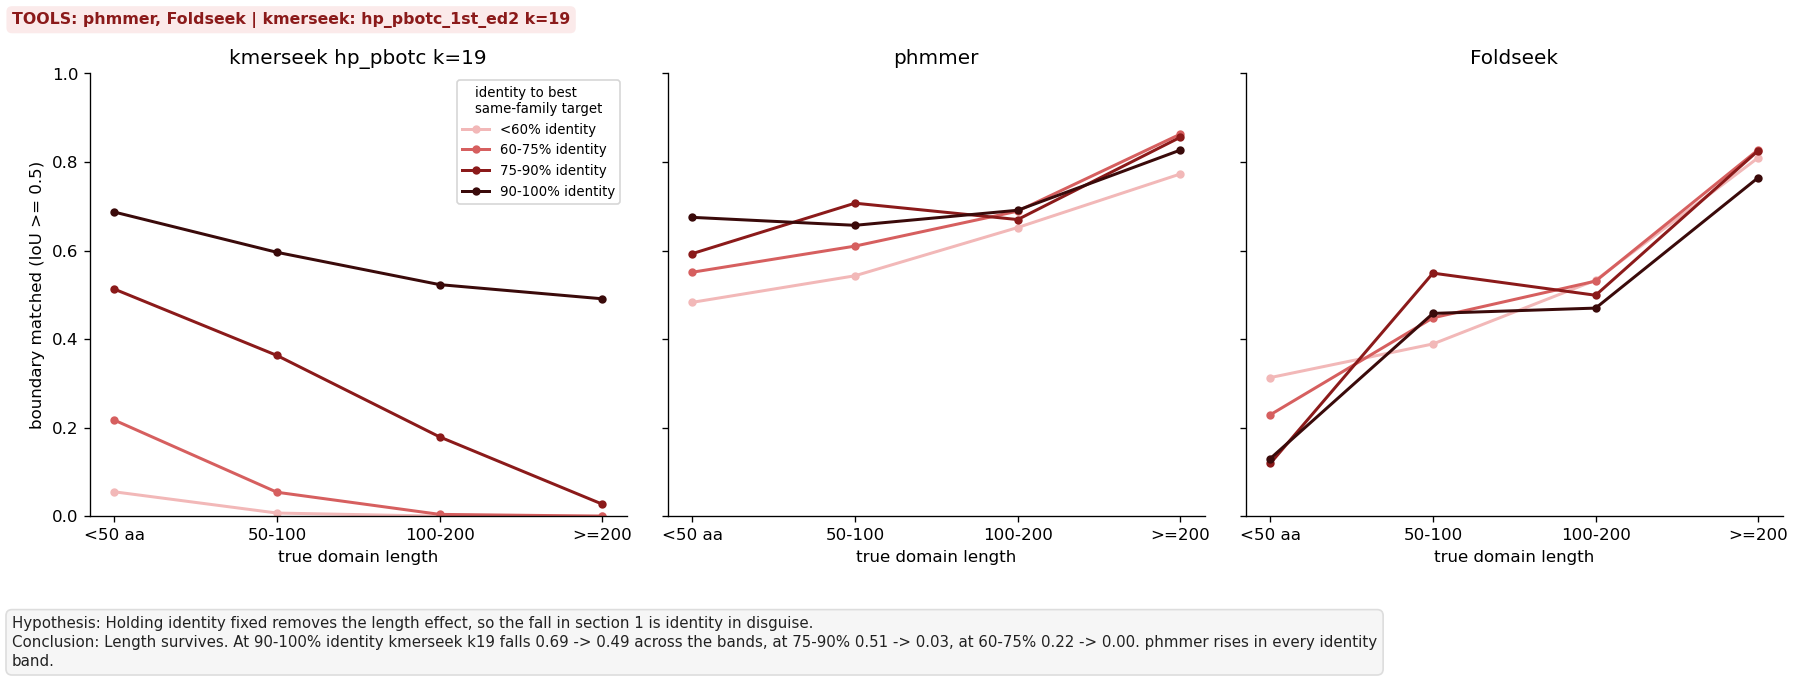

In [3]:
ids = pl.concat(
    [
        pl.read_parquet(mu.IDENTITY_DIR / f"{sp}.domain_identity.parquet")
        .group_by("accession", "pfam_id")
        .agg(pident=pl.col("best_pident").max())
        .rename({"accession": "query_acc"})
        .with_columns(species=pl.lit(sp))
        for sp in SP
    ]
)
GRID = GRID.join(ids, on=["query_acc", "pfam_id", "species"], how="left")
ID_BANDS = ["<60", "60-75", "75-90", "90-100"]
GRID = GRID.with_columns(
    id_band=pl.when(pl.col("pident").is_null())
    .then(pl.lit("no same-family target"))
    .when(pl.col("pident") < 60)
    .then(pl.lit("<60"))
    .when(pl.col("pident") < 75)
    .then(pl.lit("60-75"))
    .when(pl.col("pident") < 90)
    .then(pl.lit("75-90"))
    .otherwise(pl.lit("90-100"))
)

one = GRID.filter(pl.col("arm") == KM_BEST)
id_by_len = (
    one.group_by("band")
    .agg(
        n=pl.len(),
        median_identity=pl.col("pident").median(),
        frac_ge_60=(pl.col("pident") >= 60).mean().round(3),
        frac_no_target=pl.col("pident").is_null().mean().round(3),
    )
    .with_columns(_o=pl.col("band").replace_strict(dict(zip(BANDS, range(4)))))
    .sort("_o")
    .drop("_o")
)
print("Identity to the best same-family target, by domain length band:")
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(id_by_len)


def id_len_table(arm: str, col: str = "boundary_matched") -> pl.DataFrame:
    t = (
        GRID.filter((pl.col("arm") == arm) & pl.col("id_band").is_in(ID_BANDS))
        .group_by("id_band", "band")
        .agg(v=pl.col(col).mean().round(3), n=pl.len())
    )
    v = t.pivot(on="band", index="id_band", values="v").select(["id_band"] + BANDS)
    order = dict(zip(ID_BANDS, range(4)))
    return v.with_columns(_o=pl.col("id_band").replace_strict(order)).sort("_o").drop("_o")


n_tab = (
    GRID.filter((pl.col("arm") == KM_BEST) & pl.col("id_band").is_in(ID_BANDS))
    .group_by("id_band", "band")
    .agg(n=pl.len())
    .pivot(on="band", index="id_band", values="n")
    .select(["id_band"] + BANDS)
    .with_columns(_o=pl.col("id_band").replace_strict(dict(zip(ID_BANDS, range(4)))))
    .sort("_o")
    .drop("_o")
)
print()
print("cells per (identity band, length band), same for every arm:")
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(n_tab)
PANEL = [(KM_BEST, "kmerseek hp_pbotc k=19"), (PHMMER, "phmmer"), (FOLDSEEK, "Foldseek")]
for arm, label in PANEL:
    print()
    print(f"{label}, boundary matched, identity band (rows) x domain length band (columns):")
    with pl.Config(tbl_rows=10, tbl_width_chars=120):
        print(id_len_table(arm))

km_tab = id_len_table(KM_BEST)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
id_colors = dict(zip(ID_BANDS, ["#F2B8B8", "#D65F5F", "#8B1A1A", "#3A0A0A"]))
for ax, (arm, label) in zip(axes, PANEL):
    tab = id_len_table(arm)
    for r in tab.iter_rows(named=True):
        y = [r[b] for b in BANDS]
        ax.plot(x, y, "o-", color=id_colors[r["id_band"]], lw=1.8, ms=4,
                label=f"{r['id_band']}% identity")
    ax.set_xticks(x)
    ax.set_xticklabels(BAND_LABELS)
    ax.set_xlabel("true domain length")
    ax.set_title(label)
    ax.set_ylim(0, 1)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("boundary matched (IoU >= 0.5)")
axes[0].legend(fontsize=8, title="identity to best\nsame-family target", title_fontsize=8)
r90 = km_tab.filter(pl.col("id_band") == "90-100").row(0, named=True)
r75 = km_tab.filter(pl.col("id_band") == "75-90").row(0, named=True)
r60 = km_tab.filter(pl.col("id_band") == "60-75").row(0, named=True)
mu.finish_figure(
    fig,
    FIG_DIR / "227_length_within_identity.png",
    tools=mu.tools_text(["hmmer3_phmmer", "foldseek"], kmerseek=[mu.BEST_KMERSEEK]),
    hypothesis="Holding identity fixed removes the length effect, so the fall in section 1 is identity in disguise.",
    conclusion=(
        f"Length survives. At 90-100% identity kmerseek k19 falls {r90['<50']:.2f} -> {r90['>=200']:.2f} "
        f"across the bands, at 75-90% {r75['<50']:.2f} -> {r75['>=200']:.2f}, at 60-75% "
        f"{r60['<50']:.2f} -> {r60['>=200']:.2f}. phmmer rises in every identity band."
    ),
    footer_y=-0.06,
)

Identity explains some of section 1 and none of its shape. Within every identity band
kmerseek still falls with length, and the fall gets steeper as identity drops: about 1.4-fold
at 90-100% identity, 19-fold at 75-90%, and at 60-75% identity the two longest bands are
0.004 and 0. phmmer rises with length in every identity band. Foldseek rises in every band
too, and its short-domain weakness is present at every identity, which says the same
thing from the other side: for the alignment and structure tools length is a help, for
kmerseek it is a cost, and the cost grows as sequences diverge.

That interaction is the signature to explain. If long domains were simply harder for
kmerseek by a fixed factor, the ratio between bands would be the same in every identity
row. It is not; the length penalty is mild when sequences are near-identical and severe
when they are not.

## 3. The same picture per species

Identity and divergence time are nearly the same axis here, so the species split should
show the same interaction with distance.

kmerseek hp_pbotc k=19, boundary matched, species x length band:
shape: (9, 5)
┌─────────────┬───────┬────────┬─────────┬───────┐
│ species     ┆ <50   ┆ 50-100 ┆ 100-200 ┆ >=200 │
│ ---         ┆ ---   ┆ ---    ┆ ---     ┆ ---   │
│ str         ┆ f64   ┆ f64    ┆ f64     ┆ f64   │
╞═════════════╪═══════╪════════╪═════════╪═══════╡
│ mouse       ┆ 0.593 ┆ 0.444  ┆ 0.389   ┆ 0.258 │
│ chicken     ┆ 0.311 ┆ 0.21   ┆ 0.118   ┆ 0.088 │
│ zebrafish   ┆ 0.491 ┆ 0.229  ┆ 0.078   ┆ 0.037 │
│ ciona       ┆ 0.326 ┆ 0.068  ┆ 0.014   ┆ 0.009 │
│ fly         ┆ 0.274 ┆ 0.079  ┆ 0.014   ┆ 0.006 │
│ worm        ┆ 0.3   ┆ 0.072  ┆ 0.013   ┆ 0.007 │
│ yeast       ┆ 0.263 ┆ 0.004  ┆ 0.0     ┆ 0.0   │
│ arabidopsis ┆ 0.182 ┆ 0.028  ┆ 0.004   ┆ 0.0   │
│ ecoli       ┆ 0.125 ┆ 0.0    ┆ 0.0     ┆ 0.0   │
└─────────────┴───────┴────────┴─────────┴───────┘

phmmer, boundary matched, species x length band:
shape: (9, 5)
┌─────────────┬───────┬────────┬─────────┬───────┐
│ species     ┆ <50   ┆ 50-100 ┆ 100-200 

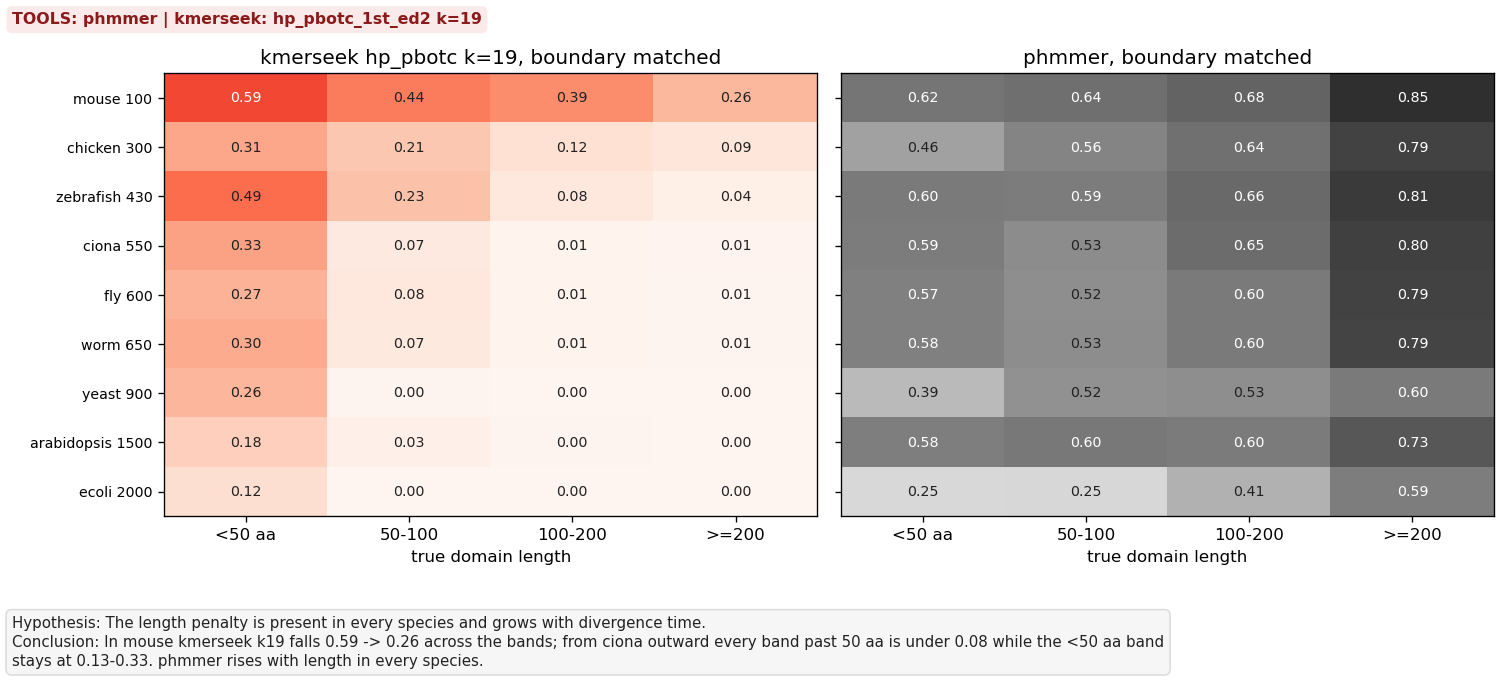

In [4]:
sp_tab = (
    GRID.filter(pl.col("arm").is_in([KM_BEST, PHMMER]))
    .group_by("arm", "species", "band")
    .agg(v=pl.col("boundary_matched").mean().round(3), n=pl.len())
)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for ax, (arm, label) in zip(axes, PANEL[:2]):
    m = np.zeros((len(SP), 4))
    for i, sp in enumerate(SP):
        for j, b in enumerate(BANDS):
            m[i, j] = sp_tab.filter(
                (pl.col("arm") == arm) & (pl.col("species") == sp) & (pl.col("band") == b)
            )["v"][0]
    im = ax.imshow(m, vmin=0, vmax=1, cmap="Reds" if "kmerseek" in arm else "Greys", aspect="auto")
    for i in range(len(SP)):
        for j in range(4):
            ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                    color="white" if m[i, j] > 0.55 else "#222222")
    ax.set_xticks(range(4))
    ax.set_xticklabels(BAND_LABELS)
    ax.set_yticks(range(len(SP)))
    ax.set_yticklabels([f"{sp} {mu.SPECIES_MYA[sp]}" for sp in SP], fontsize=8.5)
    ax.set_xlabel("true domain length")
    ax.set_title(f"{label}, boundary matched")
    print(f"{label}, boundary matched, species x length band:")
    print(
        pl.DataFrame({"species": SP, **{b: m[:, j].round(3) for j, b in enumerate(BANDS)}})
    )
    print()
mu.finish_figure(
    fig,
    FIG_DIR / "227_length_by_species.png",
    tools=mu.tools_text(["hmmer3_phmmer"], kmerseek=[mu.BEST_KMERSEEK]),
    hypothesis="The length penalty is present in every species and grows with divergence time.",
    conclusion=(
        "In mouse kmerseek k19 falls 0.59 -> 0.26 across the bands; from ciona outward every band "
        "past 50 aa is under 0.08 while the <50 aa band stays at 0.13-0.33. phmmer rises with "
        "length in every species."
    ),
    footer_y=-0.06,
)

## 4. Why: a region is one unbroken run, and a call needs half the domain

Two steps between a kmerseek hit and a scored domain call, both length-dependent.

**A kmerseek region is a gapless run of shared k-mers.** `find_matched_regions` in
`kmerseek/src/rust/search.rs` sorts the shared k-mers by query position and extends a
region only while both the query and target positions advance by exactly one. The first
residue whose encoded letter differs between query and target breaks k consecutive k-mers,
and the region ends there. A region is therefore never longer than the stretch between two
substitutions that change the reduced-alphabet letter. In the HP alphabet an L→V does not
break a run and an L→K does.

**A region only becomes a domain call if it covers half the target-side domain.**
`transfer_domains` in `evaluate_domain_calls.py` labels a region with a target Pfam family
only when the region overlaps at least `--min-overlap` (0.5) of that domain's length on
the target. Then the query side is scored at IoU ≥ 0.5 against the true domain.

Put together: to match the boundary of a domain of length L, kmerseek needs one run of at least L/2
residues with no letter-changing substitution anywhere inside it. For a 40-aa domain that
is a 20-residue clean stretch; for a 300-aa domain it is a 150-residue one. If substitutions
land at a constant rate per residue, the probability of a clean run of length L/2 falls
exponentially in L, and falls faster the higher the rate. That is the interaction in
section 2: a mild penalty near 100% identity, a severe one at 75-90%, and near-total loss
at 60-75%.

The cell below is a model, not a measurement. It takes a substitution rate per residue in
the reduced alphabet and computes, for each domain length, the chance that some window of
half the domain is free of substitutions. The rates are illustrative; nothing here
estimates the true rate.

Model: P(clean run >= L/2) at four domain lengths, per substitution rate:
shape: (5, 5)
┌───────┬───────┬───────┬───────┬───────┐
│ rate  ┆ L=40  ┆ L=75  ┆ L=150 ┆ L=300 │
│ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
╞═══════╪═══════╪═══════╪═══════╪═══════╡
│ 0.005 ┆ 0.995 ┆ 0.985 ┆ 0.944 ┆ 0.825 │
│ 0.01  ┆ 0.981 ┆ 0.947 ┆ 0.824 ┆ 0.554 │
│ 0.02  ┆ 0.935 ┆ 0.829 ┆ 0.549 ┆ 0.193 │
│ 0.04  ┆ 0.796 ┆ 0.555 ┆ 0.187 ┆ 0.015 │
│ 0.08  ┆ 0.491 ┆ 0.185 ┆ 0.013 ┆ 0.0   │
└───────┴───────┴───────┴───────┴───────┘


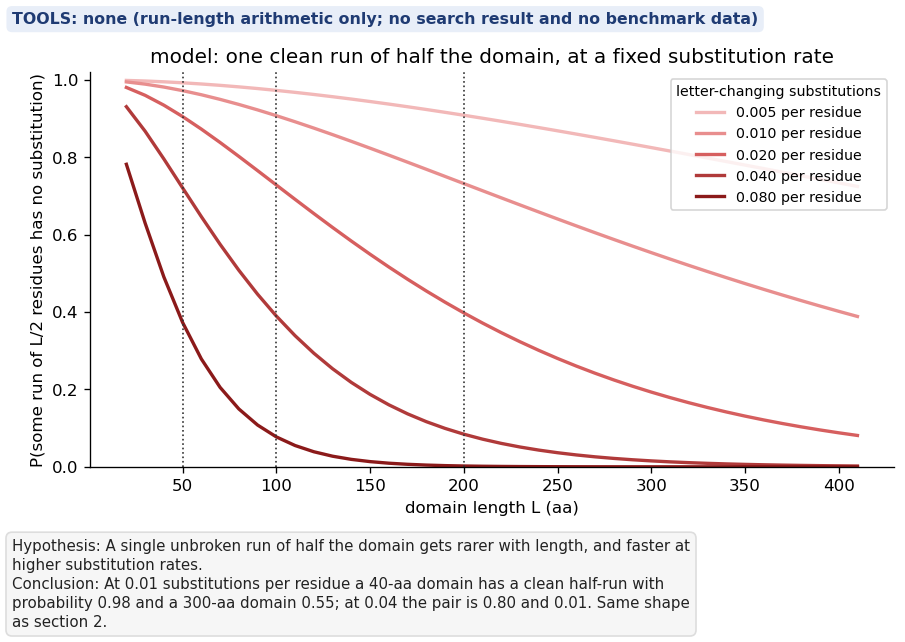

In [5]:
def p_clean_run(L: int, m: int, q: float) -> float:
    # Probability that L independent residues, each substituted with probability q, contain
    # a run of at least m unsubstituted residues. Standard run-length DP over the length of
    # the current clean run, capped at m (absorbing).
    state = np.zeros(m + 1)
    state[0] = 1.0
    for _ in range(L):
        nxt = np.zeros(m + 1)
        nxt[0] = state[:m].sum() * q
        nxt[1:m] = state[: m - 1] * (1 - q)
        nxt[m] = state[m] + state[m - 1] * (1 - q)
        state = nxt
    return float(state[m])


lengths = np.arange(20, 420, 10)
rates = [0.005, 0.01, 0.02, 0.04, 0.08]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
shades = ["#F2B8B8", "#E88E8E", "#D65F5F", "#B03A3A", "#8B1A1A"]
rows = []
for q, c in zip(rates, shades):
    p = [p_clean_run(int(L), int(np.ceil(L / 2)), q) for L in lengths]
    ax.plot(lengths, p, color=c, lw=2, label=f"{q:.3f} per residue")
    rows.append({"rate": q, **{f"L={L}": round(p_clean_run(L, L // 2, q), 3) for L in (40, 75, 150, 300)}})
for xline in (50, 100, 200):
    ax.axvline(xline, color="#333333", ls=":", lw=1)
ax.set_xlabel("domain length L (aa)")
ax.set_ylabel("P(some run of L/2 residues has no substitution)")
ax.set_title("model: one clean run of half the domain, at a fixed substitution rate")
ax.set_ylim(0, 1.02)
ax.legend(title="letter-changing substitutions", fontsize=8.5, title_fontsize=8.5)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
model = pl.DataFrame(rows)
print("Model: P(clean run >= L/2) at four domain lengths, per substitution rate:")
with pl.Config(tbl_rows=10, tbl_width_chars=120):
    print(model)
mu.finish_figure(
    fig,
    FIG_DIR / "227_clean_run_model.png",
    tools="none (run-length arithmetic only; no search result and no benchmark data)",
    hypothesis="A single unbroken run of half the domain gets rarer with length, and faster at higher substitution rates.",
    conclusion=(
        "At 0.01 substitutions per residue a 40-aa domain has a clean half-run with probability "
        f"{model.filter(pl.col('rate') == 0.01)['L=40'][0]:.2f} and a 300-aa domain "
        f"{model.filter(pl.col('rate') == 0.01)['L=300'][0]:.2f}; at 0.04 the pair is "
        f"{model.filter(pl.col('rate') == 0.04)['L=40'][0]:.2f} and "
        f"{model.filter(pl.col('rate') == 0.04)['L=300'][0]:.2f}. Same shape as section 2."
    ),
)

The model reproduces the shape of section 2 without any fitting: flat-ish near zero
substitution rate, a cliff that moves left as the rate rises. It is not evidence that the
rate is any particular number. The direct test needs kmerseek's regions before transfer,
which for all of chromosome 6 are on Sherlock, not in the laptop extract. The check that
would settle it is the length distribution of raw regions on domains kmerseek missed: if
those regions exist but each is shorter than half the target domain, the loss is the
transfer step, and chaining nearby runs from the same (query, target) pair before transfer
would recover them.

## 5. When kmerseek does call, the call is fine

Section 1 showed covered and boundary matched are nearly the same event for kmerseek.
Conditioning on a call being made shows the boundary side is steady across
length.

kmerseek k19, per length band:
shape: (4, 7)
┌─────────┬──────┬────────┬─────────┬──────────────────┬───────────────────────────────┬──────────────────────┐
│ band    ┆ n    ┆ called ┆ covered ┆ boundary_matched ┆ boundary_matched_given_called ┆ covered_given_called │
│ ---     ┆ ---  ┆ ---    ┆ ---     ┆ ---              ┆ ---                           ┆ ---                  │
│ str     ┆ u32  ┆ f64    ┆ f64     ┆ f64              ┆ f64                           ┆ f64                  │
╞═════════╪══════╪════════╪═════════╪══════════════════╪═══════════════════════════════╪══════════════════════╡
│ <50     ┆ 1458 ┆ 0.506  ┆ 0.447   ┆ 0.365            ┆ 0.721                         ┆ 0.882                │
│ 50-100  ┆ 3487 ┆ 0.228  ┆ 0.217   ┆ 0.171            ┆ 0.749                         ┆ 0.952                │
│ 100-200 ┆ 3252 ┆ 0.13   ┆ 0.125   ┆ 0.097            ┆ 0.744                         ┆ 0.967                │
│ >=200   ┆ 2450 ┆ 0.072  ┆ 0.068   ┆ 0.06             ┆ 0.

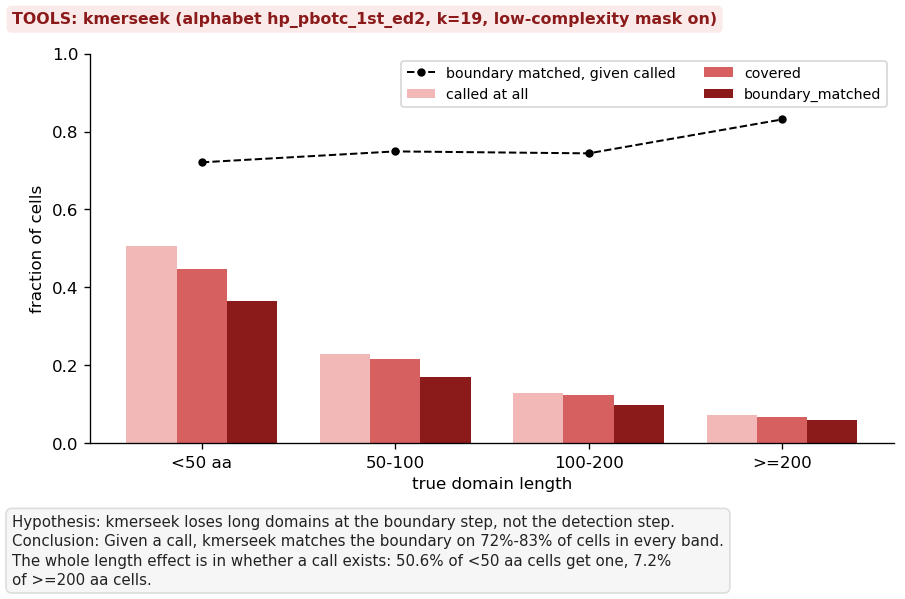

In [6]:
cond = (
    GRID.filter(pl.col("arm") == KM_BEST)
    .group_by("band")
    .agg(
        n=pl.len(),
        called=pl.col("called").mean().round(3),
        covered=pl.col("covered").mean().round(3),
        boundary_matched=pl.col("boundary_matched").mean().round(3),
        boundary_matched_given_called=pl.col("boundary_matched").filter(pl.col("called")).mean().round(3),
        covered_given_called=pl.col("covered").filter(pl.col("called")).mean().round(3),
    )
    .with_columns(_o=pl.col("band").replace_strict(dict(zip(BANDS, range(4)))))
    .sort("_o")
    .drop("_o")
)
print("kmerseek k19, per length band:")
with pl.Config(tbl_rows=10, tbl_width_chars=140):
    print(cond)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
w = 0.26
ax.bar(x - w, cond["called"], w, color="#F2B8B8", label="called at all")
ax.bar(x, cond["covered"], w, color="#D65F5F", label="covered")
ax.bar(x + w, cond["boundary_matched"], w, color="#8B1A1A", label="boundary_matched")
ax.plot(x, cond["boundary_matched_given_called"], "ko--", ms=4, lw=1.2, label="boundary matched, given called")
ax.set_xticks(x)
ax.set_xticklabels(BAND_LABELS)
ax.set_xlabel("true domain length")
ax.set_ylabel("fraction of cells")
ax.set_ylim(0, 1)
ax.legend(fontsize=8.5, ncol=2)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
mu.finish_figure(
    fig,
    FIG_DIR / "227_called_vs_boundary_matched.png",
    tools=mu.kmerseek_label(*mu.BEST_KMERSEEK),
    hypothesis="kmerseek loses long domains at the boundary step, not the detection step.",
    conclusion=(
        f"Given a call, kmerseek matches the boundary on {cond['boundary_matched_given_called'][0]:.0%}-"
        f"{cond['boundary_matched_given_called'][3]:.0%} of cells in every band. The whole length "
        f"effect is in whether a call exists: {cond['called'][0]:.1%} of <50 aa cells get one, "
        f"{cond['called'][3]:.1%} of >=200 aa cells."
    ),
)

## Summary

kmerseek recall falls with domain length while every other arm's rises. On families
present in the target, kmerseek k19 matches the boundary on 36.5% of domains under 50 aa, 17.1% of 50-100
aa, 9.7% of 100-200 aa and 6.0% of domains over 200 aa. phmmer goes 55.6%, 56.1%, 62.3%,
77.6% over the same bands; Foldseek 19.3% to 80.5%. All seven kmerseek arms fall, by 3.6-
to 6.1-fold. Below 50 aa kmerseek k19 is two thirds of phmmer and twice Foldseek. Above 200
aa it is one thirteenth of phmmer.

Identity is confounded with length in this answer key (median identity to the best
same-family target 76% for domains under 50 aa, 55% over 200 aa) and it does not explain
the shape. Within 90-100% identity kmerseek falls 0.69 → 0.49 across the bands, within
75-90% it falls 0.51 → 0.03, and within 60-75% it falls 0.22 → 0.00. phmmer rises with
length inside every identity band. The length penalty is mild for near-identical pairs and
severe for diverged ones. The species split says the same thing: mouse 0.59 → 0.26, and
from ciona outward every band past 50 aa sits under 0.08.

Given a call, kmerseek matches the boundary on 72-83% of cells in every band, so the loss is entirely in
whether a call exists.

The mechanism that fits is two length-dependent steps in series. A kmerseek region is a
gapless run of consecutive shared k-mers, so it ends at the first substitution that changes
the reduced-alphabet letter. The pipeline then labels a region with a target Pfam family only
if it covers at least half that domain on the target. Matching the boundary of a domain of length L
therefore requires one substitution-free run of L/2 residues, whose probability falls
exponentially in L at any fixed substitution rate, faster at higher rates. A run-length
model with no fitted parameters reproduces the interaction.

Three consequences. First, the short-domain end is kmerseek's regime, and the paper's
domain-level comparison should be split by length rather than pooled, where the pooled
number is dominated by the 100-200 and ≥200 aa bands where kmerseek is weakest. Second,
the penalty is a property of how regions are defined and transferred, not of k-mer
containment as such: chaining runs from the same (query, target) pair that sit within a
small gap of each other, before transfer, would let a 300-aa domain at 85% identity be
called from several 30-residue runs instead of needing one 150-residue run. That is a
kmerseek change or a pipeline-side step, and it can be tested against the raw regions on
Sherlock. Third, the direct test of the mechanism is the length distribution of raw
regions on the domains kmerseek missed, which the laptop extract does not carry.